In [11]:
from collections import defaultdict
from itertools import combinations

import polars as pl

import social_groups.polars_columns as plc
import social_groups.polars_values as plv
from social_groups.analysis.defs.notebooks.definitions import register_materialization
from social_groups.analysis.polars_transformations.apply_parsing_and_group_decision import (
    apply_parsing_and_group_decision,
)
from social_groups.reporting.group_reply import (
    GroupReplyAggregator,
    MajorityVote,
)
from social_groups.reporting.parsing import (
    AnswerComparer,
    AnswerOptions,
    AnswerParser,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
triple_underscore_handling = "wrong"

parser = AnswerParser(AnswerOptions.letters_A_to_J)
group_reply = GroupReplyAggregator(MajorityVote())
comparer = AnswerComparer(
    AnswerOptions.letters_A_to_J, triple_underscore_handling=triple_underscore_handling
)

In [13]:
from social_groups.analysis.definitions import defs

thinking_frame: pl.DataFrame = defs().load_asset_value("thinking_mad")

2026-03-20 10:16:07 +0800 - dagster - DEBUG - system - Loading file from: /Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/results/analysis/dagster/thinking_mad.parquet using PolarsParquetIOManager...


In [14]:
thinking_frame.filter(
    (pl.col("group_constellation") == "MM") & (pl.col("thinking_models") == "L")
)

shape: (100, 18)
┌───────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ id    ┆ run_id ┆ question_i ┆ phoenix_sp ┆ … ┆ question   ┆ answer_str ┆ thinking_m ┆ group_cons │
│ ---   ┆ ---    ┆ d          ┆ an_id      ┆   ┆ ---        ┆ ing        ┆ odels      ┆ tellation  │
│ i64   ┆ i64    ┆ ---        ┆ ---        ┆   ┆ str        ┆ ---        ┆ ---        ┆ ---        │
│       ┆        ┆ i64        ┆ str        ┆   ┆            ┆ str        ┆ str        ┆ str        │
╞═══════╪════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 12740 ┆ 133    ┆ 7          ┆ 9d4e4fc52e ┆ … ┆ Q: Superhe ┆ E          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ 069785     ┆   ┆ ated steam ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ at 330psi… ┆            ┆            ┆            │
│ 12741 ┆ 133    ┆ 64         ┆ 60cd72a358 ┆ … ┆ Q: Which   ┆ E          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ ade40c     ┆   ┆ of the     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ following  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ crit…      ┆            ┆            ┆            │
│ 12742 ┆ 133    ┆ 15         ┆ eb642a980a ┆ … ┆ Q: A       ┆ C          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ 77269a     ┆   ┆ telephone  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ executive  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ instr…     ┆            ┆            ┆            │
│ 12743 ┆ 133    ┆ 66         ┆ c9c0c81580 ┆ … ┆ Q: A non-c ┆ J          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ 5cc13c     ┆   ┆ ustodial   ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ parent     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ asks…      ┆            ┆            ┆            │
│ 12744 ┆ 133    ┆ 69         ┆ e8e35239a1 ┆ … ┆ Q: What    ┆ D          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ 6fd2c7     ┆   ┆ are the    ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ difficulti ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ es i…      ┆            ┆            ┆            │
│ …     ┆ …      ┆ …          ┆ …          ┆ … ┆ …          ┆ …          ┆ …          ┆ …          │
│ 13335 ┆ 133    ┆ 99         ┆ 46c7baf639 ┆ … ┆ Q: A       ┆ B          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ 33e84a     ┆   ┆ defendant  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ and his    ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ friend …   ┆            ┆            ┆            │
│ 13336 ┆ 133    ┆ 97         ┆ 3288662145 ┆ … ┆ Q: An      ┆ C          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ 58463e     ┆   ┆ integer c  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ is a       ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ common di… ┆            ┆            ┆            │
│ 13337 ┆ 133    ┆ 98         ┆ dcbb3d34c2 ┆ … ┆ Q: The     ┆ D          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ df6e94     ┆   ┆ most       ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ prominent  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ feature …  ┆            ┆            ┆            │
│ 13338 ┆ 133    ┆ 80         ┆ d7655fd54f ┆ … ┆ Q: The     ┆ B          ┆ L          ┆ MM         │
│       ┆        ┆            ┆ 01c791     ┆

In [15]:
thinking_frame.head()

shape: (5, 18)
┌───────┬────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬────────────┐
│ id    ┆ run_id ┆ question_i ┆ phoenix_sp ┆ … ┆ question   ┆ answer_str ┆ thinking_m ┆ group_cons │
│ ---   ┆ ---    ┆ d          ┆ an_id      ┆   ┆ ---        ┆ ing        ┆ odels      ┆ tellation  │
│ i64   ┆ i64    ┆ ---        ┆ ---        ┆   ┆ str        ┆ ---        ┆ ---        ┆ ---        │
│       ┆        ┆ i64        ┆ str        ┆   ┆            ┆ str        ┆ str        ┆ str        │
╞═══════╪════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪════════════╡
│ 11340 ┆ 121    ┆ 25         ┆ 45942f7c45 ┆ … ┆ Q: What    ┆ J          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 3b81f3     ┆   ┆ stable     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ isotope is ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ comm…      ┆            ┆            ┆            │
│ 11341 ┆ 121    ┆ 0          ┆ 52ca872339 ┆ … ┆ Q: What    ┆ B          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ e4b0d9     ┆   ┆ will       ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ happen to  ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ the equ…   ┆            ┆            ┆            │
│ 11342 ┆ 121    ┆ 32         ┆ 8a1a264ccf ┆ … ┆ Q: In      ┆ C          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 2cda6c     ┆   ┆ building a ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ linear     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ regres…    ┆            ┆            ┆            │
│ 11343 ┆ 121    ┆ 26         ┆ c2d224ef0a ┆ … ┆ Q: An      ┆ I          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 3056ff     ┆   ┆ electric   ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ dipole     ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ consisti…  ┆            ┆            ┆            │
│ 11344 ┆ 121    ┆ 31         ┆ 57a4af65ef ┆ … ┆ Q:  When   ┆ A          ┆ H          ┆ MM         │
│       ┆        ┆            ┆ 83e8f7     ┆   ┆ was the    ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ major      ┆            ┆            ┆            │
│       ┆        ┆            ┆            ┆   ┆ shift b…   ┆            ┆            ┆            │
└───────┴────────┴────────────┴────────────┴───┴────────────┴────────────┴────────────┴────────────┘

In [16]:
parsed = apply_parsing_and_group_decision(thinking_frame, parser, comparer, group_reply)

In [17]:
main_results = (
    parsed.group_by([plc.group_constellation, plc.thinking_models]).agg(
        pl.mean(plc.is_correct).alias(plc.accuracy)
    )
).sort(plc.accuracy, plc.group_constellation, "thinking_models", descending=True)
register_materialization(
    "thinking_mad_evaluation_table",
    main_results,
    description="Different settings of thinking models in different group constellations using MAD and their respective accuracy.",
)

Skipping Materialization because in interactive mode.


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass


In [18]:
main_results

group_constellation,thinking_models,accuracy
str,str,f64
"""HHH""","""L""",0.76
"""HH""","""everyone""",0.76
"""HH""","""H""",0.76
"""HHM""","""nobody""",0.74
"""HHH""","""nobody""",0.73
…,…,…
"""LLL""","""H""",0.33
"""LLL""","""nobody""",0.31
"""LL""","""everyone""",0.31


In [19]:
thinking_data = (
    main_results.pivot(
        plc.thinking_models, index=plc.group_constellation, values=plc.accuracy
    )
    .with_columns(
        (
            pl.col(plv.thinking_models.everyone) - pl.col(plv.thinking_models.nobody)
        ).alias("full thinking vs. no thinking")
    )
    .sort("full thinking vs. no thinking", descending=True)
)

In [20]:
register_materialization(
    "mad_evaluation_table_per_group_constellation_with_different_thinking_models",
    thinking_data,
    description="Different group constellations and their accuracies based on who in the group is allowed to think. It also shows the difference in allowing everyone or noone to think.",
)
thinking_data

Skipping Materialization because in interactive mode.


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass


group_constellation,L,everyone,H,nobody,full thinking vs. no thinking
str,f64,f64,f64,f64,f64
"""LLL""",0.34,0.41,0.33,0.31,0.1
"""LM""",0.45,0.52,0.45,0.44,0.08
"""HH""",0.7,0.76,0.76,0.68,0.08
"""LL""",0.34,0.31,0.28,0.25,0.06
"""MM""",0.58,0.61,0.47,0.55,0.06
…,…,…,…,…,…
"""HHM""",0.72,0.7,0.66,0.74,-0.04
"""HM""",0.65,0.61,0.59,0.65,-0.04
"""HHL""",0.61,0.65,0.66,0.7,-0.05


Skipping Materialization because in interactive mode.


/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagstermill/manager.py:286: BetaWarning: Class `DagstermillExecutionContext` is currently in beta, and may have breaking changes in minor version releases, with behavior changes in patch releases.
  self.context = DagstermillExecutionContext(
/Users/philipp/Documents/Studium/Informatik/Masterthesis/Repository/.venv/lib/python3.11/site-packages/dagster/_core/execution/context_creation_job.py:276: RuntimeWarning: coroutine 'BaseEventLoop.shutdown_asyncgens' was never awaited
  pass


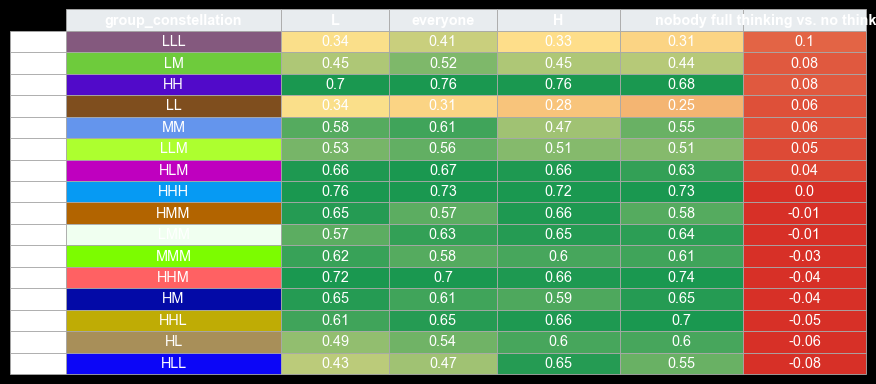

In [21]:
import random

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, get_named_colors_mapping

data = thinking_data.with_columns(
    pl.col("full thinking vs. no thinking").round(2)
).to_numpy()

col_labels = list(thinking_data.columns)
row_labels = [f"Run {i + 1}" for i in range(len(data))]

# ────────────────────────────────────────────────
# Color gradient: red → white → green for accuracy
# ────────────────────────────────────────────────

colors = ["#d73027", "#fee08b", "#1a9850"]  # red – light yellow – green
all_colors = list(get_named_colors_mapping().values())
cmap = LinearSegmentedColormap.from_list("acc", colors, N=256)


def acc_to_color(value):
    """Map accuracy [0,1] → color"""
    # Optional: clip just in case
    v = max(0.0, min(1.0, float(value)))
    return cmap(v)


# ────────────────────────────────────────────────
# Build 2D list of cell background colors
# ────────────────────────────────────────────────

category_colors = defaultdict(lambda: random.choice(all_colors))

cell_colors = []
for row in data:
    row_colors = []
    for j, val in enumerate(row):
        if j >= 1:  # accuracy column (0-based index 3)
            color = acc_to_color(val * 1.5)
        else:
            color = category_colors[val]
        row_colors.append(color)
    cell_colors.append(row_colors)

# ────────────────────────────────────────────────
# Create figure and table
# ────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 4.2))  # adjust as needed
ax.axis("off")

table = ax.table(
    cellText=data,
    cellColours=cell_colors,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
    colWidths=[0.28, 0.14, 0.14, 0.16, 0.16, 0.16],
)

table.auto_set_font_size(False)
table.set_fontsize(10.4)
table.scale(1.2, 1.6)  # horizontal / vertical stretch

# Optional: nicer grid
for (i, j), cell in table.get_celld().items():
    cell.set_edgecolor("#aaaaaa")
    cell.set_linewidth(0.6)
    # Make header row bold / different bg
    if i == 0:
        cell.set_facecolor("#e8ecef")
        cell.set_text_props(weight="bold")

# Optional title

plt.tight_layout()
register_materialization(
    "thinking_mad_comparison_colored",
    fig,
    "Accuracies for different group constellations and different models allowed to think ",
)
plt.show()

# Why are there differences in supposedly equal cases?:

In [25]:
correct_per_question = parsed.sort("question_id").pivot(
    on="question_id",
    index=["thinking_models", "group_constellation"],
    values=plc.is_correct,
    aggregate_function="item",
)

In [51]:
def should_be_the_same(g1: str, g2: str, t1: str, t2: str):
    if g1 != g2:
        return False

    if t1 == t2:
        return True

    models = set(g1)

    if t1 == "nobody":
        return (t2 not in models) and (t2 != "everyone")
    elif t1 == "everyone":
        return {t2} == models
    elif t1 in models:
        return t2 == "everyone" and {t1} == models
    else:
        return (t2 == "nobody") or ((t2 not in models) and t2 != "everyone")

In [59]:
from itertools import combinations

T = correct_per_question["thinking_models"].unique().to_list()
G = correct_per_question["group_constellation"].unique().to_list()

for g in G:
    for t1 in T:
        for t2 in T:
            assert should_be_the_same(g, g, t1, t2) == should_be_the_same(g, g, t2, t1)

test_df = pl.DataFrame(
 [{"group_constellation": g, "thinking 1": t1, "thinking 2": t2, "should be the same": should_be_the_same(g, g, t2, t1)} for g in G for t1, t2 in combinations(T, 2)]
)
test_df

group_constellation,thinking 1,thinking 2,should be the same
str,str,str,bool
"""HHH""","""everyone""","""L""",false
"""HHH""","""everyone""","""nobody""",false
"""HHH""","""everyone""","""H""",true
"""HHH""","""L""","""nobody""",true
"""HHH""","""L""","""H""",false
…,…,…,…
"""HM""","""everyone""","""nobody""",false
"""HM""","""everyone""","""H""",false
"""HM""","""L""","""nobody""",true


###### Now find the questions that should be the same, but are not:

In [63]:
correct_per_question

thinking_models,group_constellation,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,…,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119
str,str,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,…,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
"""H""","""MM""",true,false,true,false,false,true,false,true,false,false,true,true,true,true,true,true,false,false,false,false,true,false,false,false,false,true,false,true,false,true,false,false,false,false,true,…,true,true,true,true,false,true,false,false,false,false,false,true,true,true,true,false,false,true,false,true,true,false,true,true,true,true,false,true,false,false,true,false,false,false,true,false,false
"""L""","""HL""",true,false,false,false,true,false,true,false,false,true,false,false,false,true,true,false,false,true,true,false,false,false,true,false,false,true,true,false,false,true,true,false,false,true,false,…,true,false,true,true,false,false,false,false,true,false,false,true,true,true,true,true,true,true,false,false,true,true,true,true,true,false,false,true,false,true,false,true,false,true,false,true,true
"""L""","""LM""",true,false,false,false,true,true,true,true,false,false,false,true,true,true,false,true,false,true,true,false,false,false,false,false,false,true,true,false,false,true,true,false,false,false,false,…,false,false,false,true,false,false,false,false,false,true,true,true,true,false,true,true,false,true,false,false,true,false,true,true,true,true,false,true,false,false,true,false,false,true,false,false,false
"""H""","""HH""",true,true,true,false,false,true,true,false,false,true,true,true,true,true,true,true,false,true,true,true,true,false,true,false,true,true,true,true,false,false,true,true,false,true,false,…,true,true,true,true,true,true,true,false,true,false,false,true,true,true,true,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,true,false,true,true,true
"""nobody""","""LM""",true,false,false,false,false,false,false,false,false,true,false,true,true,true,false,false,false,false,true,false,false,false,true,false,false,false,true,true,false,true,true,false,false,false,false,…,false,false,true,true,false,false,true,false,true,false,false,true,true,false,true,true,false,true,false,false,true,false,false,true,true,true,false,true,false,false,true,false,true,false,true,false,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""everyone""","""LLL""",true,false,false,false,false,false,true,false,false,false,false,true,false,true,false,true,false,false,true,false,false,false,false,false,false,true,true,false,true,true,true,false,false,false,true,…,true,false,false,true,false,false,false,false,false,false,true,true,true,false,false,true,false,true,true,false,false,true,false,true,false,false,true,true,false,false,false,true,false,false,false,false,true
"""everyone""","""HLM""",true,false,true,false,true,true,true,true,false,true,true,true,true,true,true,true,false,true,true,false,true,false,true,false,true,true,true,true,false,false,true,false,false,false,false,…,false,true,true,true,false,true,true,false,true,false,false,true,true,true,true,true,false,true,false,true,true,false,true,true,true,true,false,true,true,false,true,true,false,false,true,true,true
"""everyone""","""HHL""",true,false,true,false,true,true,true,false,false,true,true,true,true,true,true,false,false,true,true,true,true,false,true,false,true,true,true,false,false,true,true,false,false,true,false,…,true,true,true,true,true,true,true,false,false,false,false,false,true,true,true,

In [80]:
import polars as pl
from typing import Any, Callable, List
value_cols: List[str] = [col for col in correct_per_question.columns if col not in {plc.thinking_models, plc.group_constellation}]
rows = correct_per_question.to_dicts()

results = []
for i in range(len(rows)):
    for j in range(len(rows)):
        if i == j:
            continue

        row1 = rows[i]
        row2 = rows[j]


        g1, t1 = row1[plc.group_constellation], row1[plc.thinking_models]
        g2, t2 = row2[plc.group_constellation], row2[plc.thinking_models]

        if should_be_the_same(g1, g2, t1, t2):
            mismatches = [
                col for col in value_cols
                if row1[col] != row2[col]
            ]
            assert g1 == g2
            if mismatches:
                results.append({
                    plc.group_constellation: g1,
                    "t1": t1,
                    "t2": t2,
                    "mismatching_columns": mismatches
                })
mismatching = pl.DataFrame(results).sort([plc.group_constellation, "t1", "t2"]).with_columns(number_of_mismatches=pl.col("mismatching_columns").list.len())

from polars.testing import assert_frame_equal

assert_frame_equal(mismatching, mismatching.with_columns(t2=pl.col("t1"), t1=pl.col("t2")).sort([plc.group_constellation, "t1", "t2"]), check_exact=True)

mismatching = mismatching.filter(pl.col("t1") <= pl.col("t2")).sort("number_of_mismatches", descending=True)
mismatching

group_constellation,t1,t2,mismatching_columns,number_of_mismatches
str,str,str,list[str],u32
"""LL""","""L""","""everyone""","[""0"", ""10"", … ""119""]",31
"""LLM""","""H""","""nobody""","[""4"", ""5"", … ""119""]",26
"""LLL""","""H""","""nobody""","[""3"", ""13"", … ""118""]",22
"""LM""","""H""","""nobody""","[""5"", ""6"", … ""117""]",21
"""HMM""","""L""","""nobody""","[""6"", ""9"", … ""119""]",19
…,…,…,…,…
"""LMM""","""H""","""nobody""","[""5"", ""19"", … ""118""]",11
"""MM""","""L""","""nobody""","[""4"", ""7"", … ""118""]",11
"""HHH""","""L""","""nobody""","[""27"", ""31"", … ""114""]",9


In [99]:
used_case = mismatching[0]

print(used_case)
mismatching_ids = used_case["mismatching_columns"].item().to_list()
mismatching_gc = used_case[plc.group_constellation].item()
mt1 = used_case["t1"].item()
mt2 = used_case["t2"].item()

parsed.filter(pl.col(plc.group_constellation) == mismatching_gc, pl.col(plc.thinking_models).is_in({mt1, mt2}), pl.col("question_id").is_in(set(map(int, mismatching_ids)))).pivot(index="question_id", on=["thinking_models", "group_constellation"], values="phoenix_span_url").sort("question_id").to_pandas(use_pyarrow_extension_array=True).set_index("question_id")

shape: (1, 5)
┌─────────────────────┬─────┬──────────┬──────────────────────┬──────────────────────┐
│ group_constellation ┆ t1  ┆ t2       ┆ mismatching_columns  ┆ number_of_mismatches │
│ ---                 ┆ --- ┆ ---      ┆ ---                  ┆ ---                  │
│ str                 ┆ str ┆ str      ┆ list[str]            ┆ u32                  │
╞═════════════════════╪═════╪══════════╪══════════════════════╪══════════════════════╡
│ LL                  ┆ L   ┆ everyone ┆ ["0", "10", … "119"] ┆ 31                   │
└─────────────────────┴─────┴──────────┴──────────────────────┴──────────────────────┘


,"{""L"",""LL""}","{""everyone"",""LL""}"
question_id,,
0,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
10,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
15,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
16,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
17,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
25,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
28,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
30,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
38,http://localhost:6006/projects/UHJvamVjdDo5Mg=...,http://localhost:6006/projects/UHJvamVjdDozOQ=...
